In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from multiprocessing import Pool, cpu_count
import time

# 加载评分函数
from utils import evaluate_pulse

# 设置中文字体支持
rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False


In [ ]:
# 运行次数
iters_num = 10

# 相位
phi = 0.0

# 加载脉冲
pulses_1 = np.load('results/pulses_spsa_gaussian.npy')  # Shape: (30, 2)
pulses_2 = np.load("results/pulses_spsa_random.npy")
pulses_3 = np.load("results/closed_system_pulses.npy") # 在闭合系统中优化得到的脉冲，运行速度1分钟左右，迭代很快


In [ ]:
print(f"开始并行评分 {iters_num} 次...")
print(f"使用 CPU 核心数: {cpu_count()}")

# 准备并行计算参数
args_list_1 = [(pulses_1, phi, False) for _ in range(iters_num)]
args_list_2 = [(pulses_2, phi, False) for _ in range(iters_num)]
args_list_3 = [(pulses_3, phi, False) for _ in range(iters_num)]

# 使用多进程并行计算
start_time = time.time()
with Pool() as pool:
    # 并行计算两组脉冲的评分
    results_1 = pool.map(evaluate_pulse, args_list_1)
    results_2 = pool.map(evaluate_pulse, args_list_2)
    results_3 = pool.map(evaluate_pulse, args_list_3)
end_time = time.time()

# 提取结果
score_list_1 = [r[0] for r in results_1]
gate_error_list_1 = [r[1] for r in results_1]
gate_fidelity_list_1 = [r[2] for r in results_1]
leakage_list_1 = [r[3] for r in results_1]
penalty_list_1 = [r[4] for r in results_1]

score_list_2 = [r[0] for r in results_2]
gate_error_list_2 = [r[1] for r in results_2]
gate_fidelity_list_2 = [r[2] for r in results_2]
leakage_list_2 = [r[3] for r in results_2]
penalty_list_2 = [r[4] for r in results_2]

score_list_3 = [r[0] for r in results_3]
gate_error_list_3 = [r[1] for r in results_3]
gate_fidelity_list_3 = [r[2] for r in results_3]
leakage_list_3 = [r[3] for r in results_3]
penalty_list_3 = [r[4] for r in results_3]

print(f"并行计算耗时: {end_time - start_time:.2f} 秒")

# 打印统计信息
print("\n=== pulses_spsa_gaussian 统计信息 ===")
print(f"平均评分: {np.mean(score_list_1):.6f} ± {np.std(score_list_1):.6f}")
print(f"门错误: {np.mean(gate_error_list_1):.6f} ± {np.std(gate_error_list_1):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_1):.6f} ± {np.std(gate_fidelity_list_1):.6f}")
print(f"泄漏: {np.mean(leakage_list_1):.6f} ± {np.std(leakage_list_1):.6f}")
print(f"惩罚: {np.mean(penalty_list_1):.6f} ± {np.std(penalty_list_1):.6f}")

print("\n=== pulses_spsa_random 统计信息 ===")
print(f"平均评分: {np.mean(score_list_2):.6f} ± {np.std(score_list_2):.6f}")
print(f"门错误: {np.mean(gate_error_list_2):.6f} ± {np.std(gate_error_list_2):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_2):.6f} ± {np.std(gate_fidelity_list_2):.6f}")
print(f"泄漏: {np.mean(leakage_list_2):.6f} ± {np.std(leakage_list_2):.6f}")
print(f"惩罚: {np.mean(penalty_list_2):.6f} ± {np.std(penalty_list_2):.6f}")

print("\n=== closed_system_pulses 统计信息 ===")
print(f"平均评分: {np.mean(score_list_3):.6f} ± {np.std(score_list_3):.6f}")
print(f"门错误: {np.mean(gate_error_list_3):.6f} ± {np.std(gate_error_list_3):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_3):.6f} ± {np.std(gate_fidelity_list_3):.6f}")
print(f"泄漏: {np.mean(leakage_list_3):.6f} ± {np.std(leakage_list_3):.6f}")
print(f"惩罚: {np.mean(penalty_list_3):.6f} ± {np.std(penalty_list_3):.6f}")

开始并行评分 10 次...
使用 CPU 核心数: 10


/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/opt/miniconda3/envs/spinq_hackthon_2025/lib/python3.11/site-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/opt/miniconda3/envs/spinq_hackthon_2025

并行计算耗时: 95.23 秒

=== pulses_spsa_gaussian 统计信息 ===
平均评分: 0.999357 ± 0.000044
门错误: 0.000622 ± 0.000055
门保真度: 0.999378 ± 0.000055
泄漏: 0.999663 ± 0.000002
惩罚: 0.998107 ± 0.000000

=== pulses_spsa_random 统计信息 ===
平均评分: 0.960219 ± 0.000298
门错误: 0.046143 ± 0.000385
门保真度: 0.953857 ± 0.000385
泄漏: 0.982335 ± 0.000114
惩罚: 0.995660 ± 0.000000

=== closed_system_pulses 统计信息 ===
平均评分: 0.432219 ± 0.000098
门错误: 0.666799 ± 0.000143
门保真度: 0.333201 ± 0.000143
泄漏: 0.773949 ± 0.000593
惩罚: 0.991326 ± 0.000000


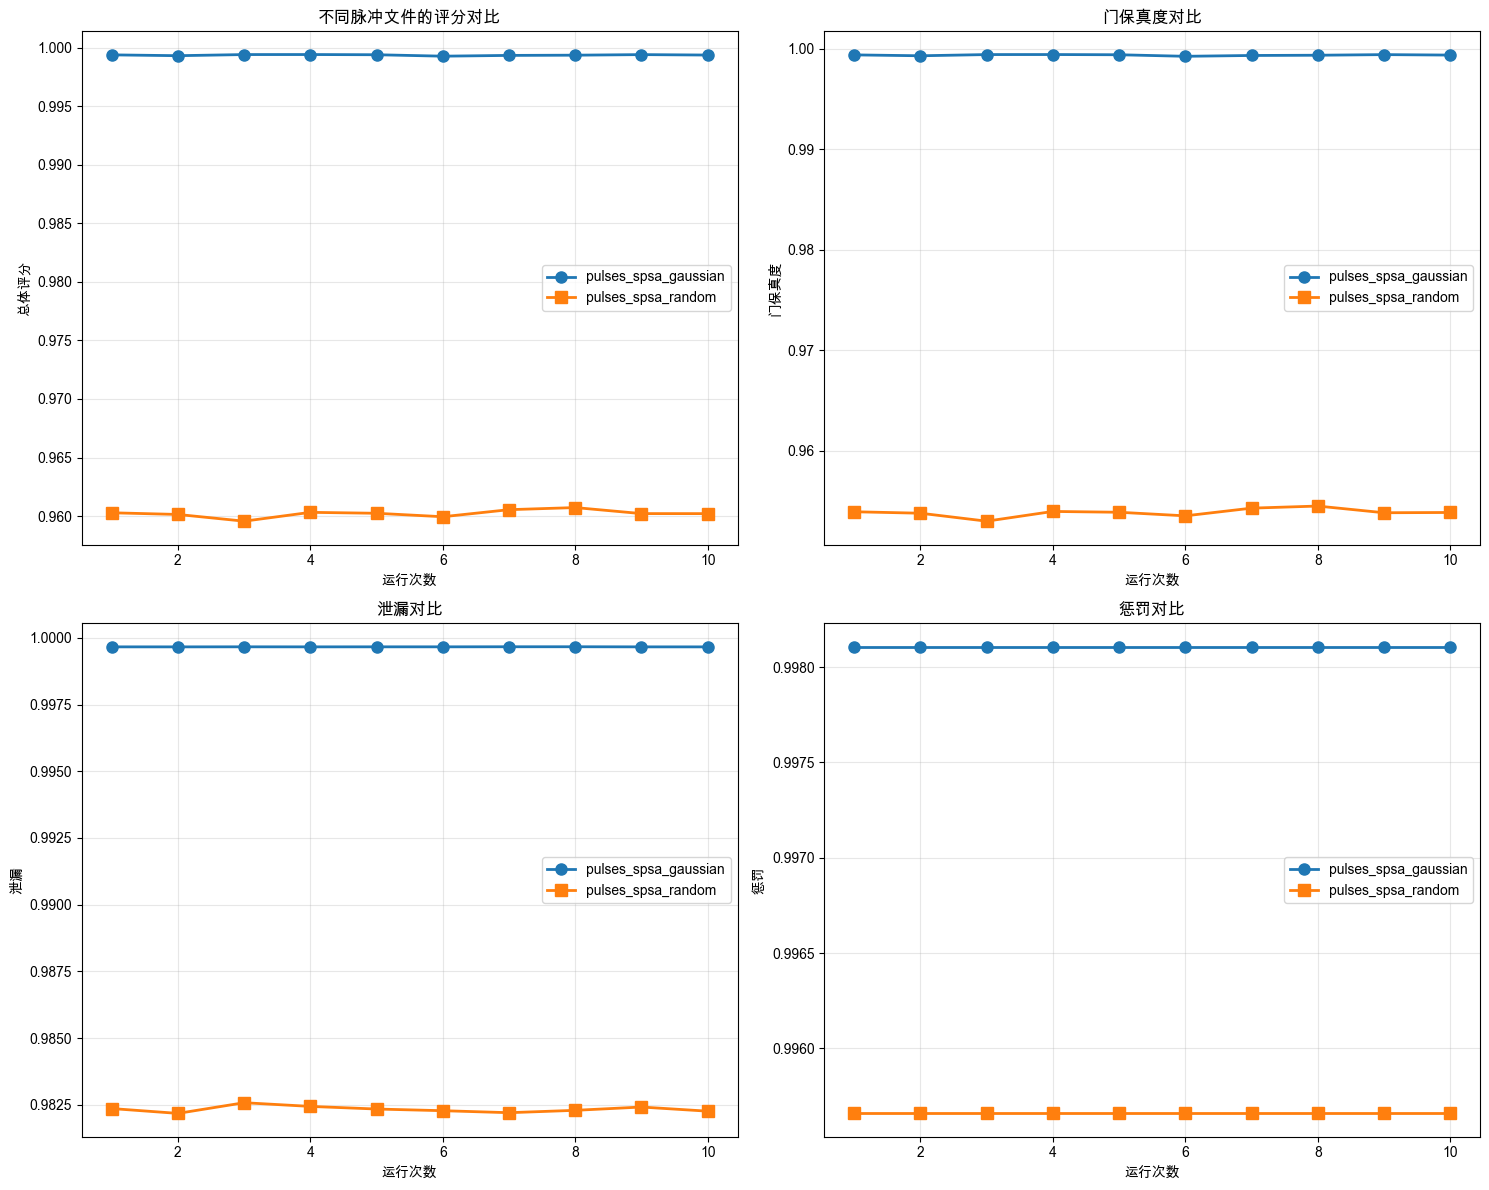

In [4]:

# 绘制详细结果
plt.figure(figsize=(15, 12))

# 子图1: 评分对比
plt.subplot(2, 2, 1)
plt.plot(range(1, iters_num+1), score_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), score_list_2, 's-', label='pulses_spsa_random', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('总体评分')
plt.title('不同脉冲文件的评分对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 门保真度对比
plt.subplot(2, 2, 2)
plt.plot(range(1, iters_num+1), gate_fidelity_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), gate_fidelity_list_2, 's-', label='pulses_spsa_random', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('门保真度')
plt.title('门保真度对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 泄漏对比
plt.subplot(2, 2, 3)
plt.plot(range(1, iters_num+1), leakage_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), leakage_list_2, 's-', label='pulses_spsa_random', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('泄漏')
plt.title('泄漏对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图4: 惩罚对比
plt.subplot(2, 2, 4)
plt.plot(range(1, iters_num+1), penalty_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), penalty_list_2, 's-', label='pulses_spsa_random', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('惩罚')
plt.title('惩罚对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

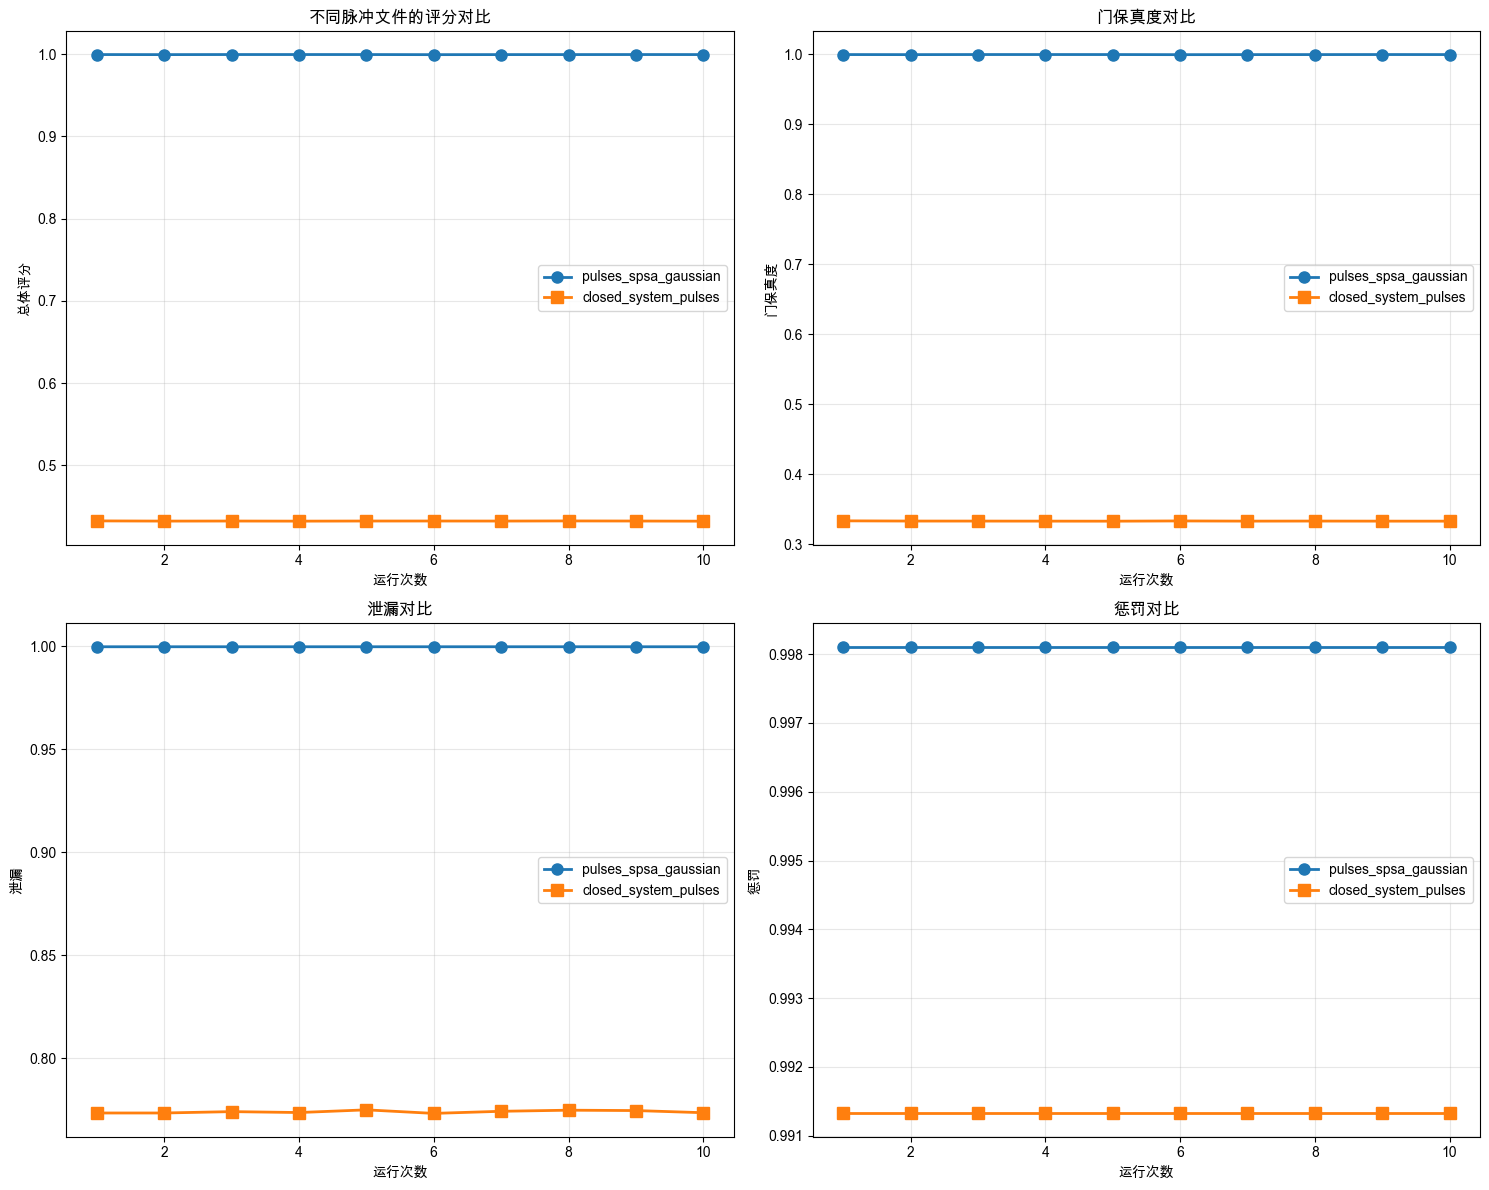

In [5]:

# 绘制详细结果
plt.figure(figsize=(15, 12))

# 子图1: 评分对比
plt.subplot(2, 2, 1)
plt.plot(range(1, iters_num+1), score_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), score_list_3, 's-', label='closed_system_pulses', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('总体评分')
plt.title('不同脉冲文件的评分对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 门保真度对比
plt.subplot(2, 2, 2)
plt.plot(range(1, iters_num+1), gate_fidelity_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), gate_fidelity_list_3, 's-', label='closed_system_pulses', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('门保真度')
plt.title('门保真度对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 泄漏对比
plt.subplot(2, 2, 3)
plt.plot(range(1, iters_num+1), leakage_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), leakage_list_3, 's-', label='closed_system_pulses', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('泄漏')
plt.title('泄漏对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图4: 惩罚对比
plt.subplot(2, 2, 4)
plt.plot(range(1, iters_num+1), penalty_list_1, 'o-', label='pulses_spsa_gaussian', linewidth=2, markersize=8)
plt.plot(range(1, iters_num+1), penalty_list_3, 's-', label='closed_system_pulses', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('惩罚')
plt.title('惩罚对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
np.max(score_list_1)

np.float64(0.9994036067597888)

In [7]:
np.max(score_list_2)

np.float64(0.9607266550828437)

In [8]:
np.max(score_list_3)

np.float64(0.43239123897756193)